In [6]:
import pandas as pd
import numpy as np
from datamodel import Order, OrderDepth, TradingState, Trade, Observation
from main2 import Trader

In [2]:
# Load Data
prices_df = pd.read_excel('../Round 1/data/prices.xlsx')
trades_df = pd.read_excel('../Round 1/data/trades.xlsx')

# Sort data for accurate sequential processing
prices_df.sort_values(by=['day', 'timestamp'], inplace=True)
trades_df.sort_values(by=['day', 'timestamp'], inplace=True)

In [3]:
# 3) Helper to turn a snapshot row into an OrderDepth
def create_order_depth(row):
    od = OrderDepth()
    for i in range(1, 4):
        bp, bv = row.get(f'bid_price_{i}'), row.get(f'bid_volume_{i}')
        if pd.notna(bp) and pd.notna(bv):
            od.buy_orders[int(bp)] = int(bv)
        ap, av = row.get(f'ask_price_{i}'), row.get(f'ask_volume_{i}')
        if pd.notna(ap) and pd.notna(av):
            od.sell_orders[int(ap)] = int(av)
    return od

In [4]:
# 4) Initialize backtest state
trader = Trader()
positions = {p: 0 for p in prices_df['product'].unique()}
trader_data = ""     # carries your history JSON between calls
cumulative_pnl = 0
pnl_history = []

In [7]:
# 5) Main backtest loop
for (day, ts), snapshot in prices_df.groupby(['day', 'timestamp']):
    # Build order books
    order_depths = {
        row['product']: create_order_depth(row)
        for _, row in snapshot.iterrows()
    }
    # Construct a TradingState (observations/listings not used by your Trader)
    state = TradingState(
        traderData=trader_data,
        timestamp=int(ts),
        listings={},
        order_depths=order_depths,
        own_trades={},
        market_trades={},
        position=positions.copy(),
        observations=Observation({}, {})
    )
    # Get your orders
    orders_dict, _, trader_data = trader.run(state)

    # Simulate execution against actual trades at this (day, ts)
    mkt = trades_df[
        (trades_df['day'] == day) &
        (trades_df['timestamp'] == ts)
    ]
    for product, orders in orders_dict.items():
        prod_trades = mkt[mkt['symbol'] == product]
        if prod_trades.empty:
            continue
        for order in orders:
            qty_wanted = abs(order.quantity)
            # buy limit → fill if trade.price ≤ your price
            if order.quantity > 0:
                fills = prod_trades[prod_trades['price'] <= order.price]
            # sell limit → fill if trade.price ≥ your price
            else:
                fills = prod_trades[prod_trades['price'] >= order.price]
            if fills.empty:
                continue

            total_vol = fills['quantity'].sum()
            filled_qty = min(qty_wanted, total_vol)
            # weighted average fill price
            avg_fill_price = (fills['price'] * fills['quantity']).sum() / total_vol

            # update position & realized PnL
            if order.quantity > 0:
                positions[product] += filled_qty
                cumulative_pnl -= avg_fill_price * filled_qty
            else:
                positions[product] -= filled_qty
                cumulative_pnl += avg_fill_price * filled_qty

    # record PnL over time
    pnl_history.append({
        'global_time': day * 10000 + ts,
        'cumulative_pnl': cumulative_pnl
    })


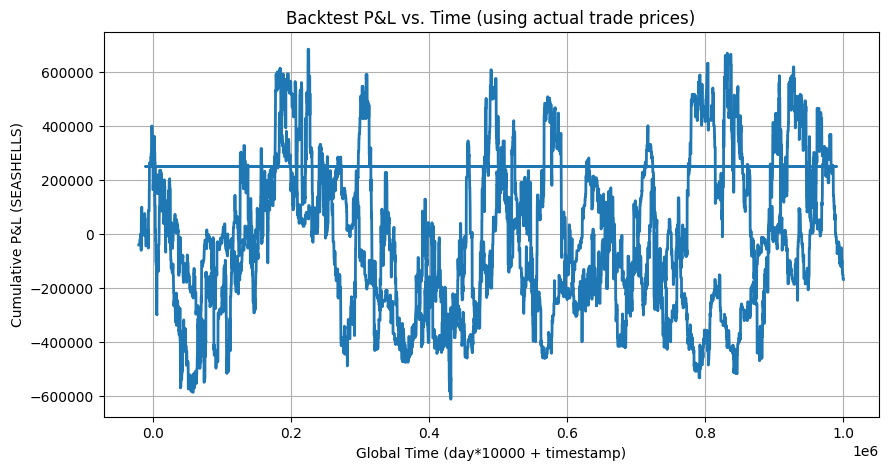

In [8]:
# 6) Plot cumulative P&L

import matplotlib.pyplot as plt

pnl_df = pd.DataFrame(pnl_history)
plt.figure(figsize=(10, 5))
plt.plot(pnl_df['global_time'], pnl_df['cumulative_pnl'], linewidth=2)
plt.xlabel('Global Time (day*10000 + timestamp)')
plt.ylabel('Cumulative P&L (SEASHELLS)')
plt.title('Backtest P&L vs. Time (using actual trade prices)')
plt.grid(True)
plt.show()

In [12]:
pnl_df.tail(10)

,global_time,cumulative_pnl
29990,999000,-148129.284848
29991,999100,-148129.284848
29992,999200,-148129.284848
29993,999300,-148129.284848
29994,999400,-148129.284848
29995,999500,-168119.284848
29996,999600,-168119.284848
29997,999700,-168119.284848
29998,999800,-168119.284848
29999,999900,-168119.284848
